# Phase 1: Project Introduction
# Tata Car Resale Price Prediction USING Machine Learning

This project ia a pratical regression machine learning poject where I work as  n ML Data Scientist to predict the resale price of Tata cars.

My aim is tp understand how car features such as model, year, mileage, fuel type, transmission, engine size, accident history, and original showroom price influence the resale value of a car.

This project follows the full Data science Lifecycle:
1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Model Building
5. Model Deployment

# Phase 2: Import Libraries

In this phase, i import the libraries needed for data loading, cleaning, analysis, visualisation, machine learning, model saving, and deployment preparations.

In [138]:
#Importing Lib.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path 

# Phase 3: Data Collection

This dataset was collected from kaggle and stored inside the data folder as a csv file. THis step is important because the data source must be clearly documented before analysis oe modelling begins.

In [139]:
data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

csv_files

[WindowsPath('../data/tata_car_price_prediction_dataset.csv')]

In [140]:
df = pd.read_csv(csv_files[0])

df.head()

,car_id,brand,model,variant,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
0,1,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2026,4978,2,1,4.48
1,2,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2022,84605,2,0,3.18
2,3,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,64915,2,0,3.18
3,4,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2023,43577,1,0,4.06
4,5,Tata,Tiago,XE,Petrol,Manual,Hatchback,1199,85,20.1,5.7,2024,40448,3,0,3.43


In [141]:
# looking at the last 5 of the datasets

df.tail()

,car_id,brand,model,variant,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
3795,3796,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2025,13895,1,0,23.99
3796,3797,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2020,76772,2,0,11.18
3797,3798,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2022,69006,1,0,15.78
3798,3799,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2026,8956,1,0,26.64
3799,3800,Tata,Safari,Accomplished AT,Diesel,Automatic,SUV,1956,168,14.5,27.0,2025,14498,1,0,24.24


# Dataset Understanding 

From the head(ist five rows of the tata_car dataset) and the tail(last five of the tata_car dataset), each row represents one Tata Car because the columns describe the car's technical, usage, ownership, and pricing details. 

One of the most important question is that 'What is the target column?'

# Answer: From the datasets, the target column is `resale_price_lakh` because the goal of this project is to predict the resale price of a Tata car. Since the target is a 'contineous numerical value', this is a 'Regression ML problem'.

The numerical columns include `engine_cc`, `power_bhp`, `mileage_kmpl`, `ex_showroom_price_lakh`, `year`, `kilometers_driven`, `owner_count`, `accident_history`, and `resale_price_lakh`.

The categorical columns include `brand`, `model`, `variant`, `fuel_type`, `transmission`, and `body_type`.

The `car_id` column is also numerical, but it is only an identifier and does not provide meaningful information for predicting resale price.

However, before cleaning or modelling, I need to understand the size, structure, and the meaning of the dataset. This helps me identify the target variable, useful features, unnecessary columns, and possible data quality issues. 

In [142]:
df.shape

(3800, 16)

This dataset contains 3,800 rows and 16 colunms. Each row represents a car record, while each column describes a feature of the car.

In [143]:
df.columns

Index(['car_id', 'brand', 'model', 'variant', 'fuel_type', 'transmission',
       'body_type', 'engine_cc', 'power_bhp', 'mileage_kmpl',
       'ex_showroom_price_lakh', 'year', 'kilometers_driven', 'owner_count',
       'accident_history', 'resale_price_lakh'],
      dtype='str')

In [144]:
list(df.columns)

['car_id',
 'brand',
 'model',
 'variant',
 'fuel_type',
 'transmission',
 'body_type',
 'engine_cc',
 'power_bhp',
 'mileage_kmpl',
 'ex_showroom_price_lakh',
 'year',
 'kilometers_driven',
 'owner_count',
 'accident_history',
 'resale_price_lakh']

The target variable is 'resale_price_lakh' because the project goal is to predict the resale price of each car. The other columns will be used as input features where needed.

# Phase 4: Data Cleaning

Data Cleaning is one of the most important stages of the D.S lifecycle. Before buildig a ML model, i need to make sure the dataset is consistent, complete and suitable for analysis. So, in this project, i check column names, missing values, deplicate records, datatypes, and unnecessary columns.

In [145]:
#Now, cleaning the column names

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("_", "_")
)

list(df.columns)

['car_id',
 'brand',
 'model',
 'variant',
 'fuel_type',
 'transmission',
 'body_type',
 'engine_cc',
 'power_bhp',
 'mileage_kmpl',
 'ex_showroom_price_lakh',
 'year',
 'kilometers_driven',
 'owner_count',
 'accident_history',
 'resale_price_lakh']

The column names are standardised by removing extra spaces, converting text to lowercase, and replacing spaces or hyphens with underscores. This makes the code neat and reduces the chance of errors(outliers) when selecting columns.

In [146]:
# Checking the dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   car_id                  3800 non-null   int64  
 1   brand                   3800 non-null   str    
 2   model                   3800 non-null   str    
 3   variant                 3800 non-null   str    
 4   fuel_type               3800 non-null   str    
 5   transmission            3800 non-null   str    
 6   body_type               3800 non-null   str    
 7   engine_cc               3800 non-null   int64  
 8   power_bhp               3800 non-null   int64  
 9   mileage_kmpl            3800 non-null   float64
 10  ex_showroom_price_lakh  3800 non-null   float64
 11  year                    3800 non-null   int64  
 12  kilometers_driven       3800 non-null   int64  
 13  owner_count             3800 non-null   int64  
 14  accident_history        3800 non-null   int64  
 15

This `info()` function shows the data types of each column and whether there are missing values. This helps me understand which columns are numerical and categorical respectively.

In [147]:
# Checking for missing values

df.isnull().sum()

car_id                    0
brand                     0
model                     0
variant                   0
fuel_type                 0
transmission              0
body_type                 0
engine_cc                 0
power_bhp                 0
mileage_kmpl              0
ex_showroom_price_lakh    0
year                      0
kilometers_driven         0
owner_count               0
accident_history          0
resale_price_lakh         0
dtype: int64

In [148]:
df.isnull()

,car_id,brand,model,variant,fuel_type,transmission,body_type,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3795,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3796,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3797,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3798,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


# Checking for Missing Values

In this step, I checked whether the dataset contains missing values.

I used:

`df.isnull()`

This checks every single cell in the dataset and returns `True` or `False`.

- `True` means the value is missing.
- `False` means the value is not missing.

However, this output can be too large and difficult to read because it shows every row and every column.

So I also used:

`df.isnull().sum()`

This gives a cleaner summary by counting the number of missing values in each column.

In my dataset, all columns returned `0`, which means there are no missing values in the dataset.

This is important because missing values can affect the performance of a machine learning model if they are not handled properly. In this, it makes the cleaning process easier.

In [149]:
# Checking duplicates

df.duplicated().sum()

np.int64(0)

There are no duplicate records in this dataset. This is good because duplicate rows can make the model over-learn repeated examples and give misleading performances.

## Phase 5: Removing unnecessary columns 

Not every column in this dataset os useful for prediction. Some columns are only identifiers and do not provide meaningful information about the resale price.

In [150]:
df = df.drop(columns=["car_id"])

The `car_id` column is removed because it is only a unique identifier for each car. It does not explain why one car is more expensive or cheaper than another.

## Phase 6: Feature Engineering

Feature Engineering means creating new useful features from existing data. In this project, I create a new feature called `car_age` from the `year` column.

Car age is important because vehicles ususally lose value as they get older. 

In [151]:
df["car_age"] = 2026 - df["year"]

df[["year", "car_age"]].head()

,year,car_age
0,2026,0
1,2022,4
2,2023,3
3,2023,3
4,2024,2


The `car_age` column represents how old the car is. This may help the model understand depreciation better than using the manufacturing year alone. E.g 
- A 2022 car is 4years old in 2026.
- A 2020 car is 6years old in 2026.

## Phase 7: Define Target Variable
The target variable is the value the ML model eill learn to predict. Since this is a car resale price prediction project, the target variable is `resale_price_lakh`.

In [152]:
target = "resale_price_lakh"

df[target].head()

0    4.48
1    3.18
2    3.18
3    4.06
4    3.43
Name: resale_price_lakh, dtype: float64

The target column contains the resale price of each car in lakhs. This is a regression problem because the model is predicting a continueous numerical value, not a category.

## Phase 8 : EDA

Exploratory Data Analysis(EDA), helps me understand the patterns, relationships, and possible issues in the dataset before building a model.

In this stage, I explore how resale price relates to car age, kilometres driven, fuel type, transmission, accident history, and other features.

In [153]:
# Summary Statistics

df.describe()

,engine_cc,power_bhp,mileage_kmpl,ex_showroom_price_lakh,year,kilometers_driven,owner_count,accident_history,resale_price_lakh,car_age
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,1389.736842,106.736842,19.621053,11.063158,2023.032368,48849.491579,1.356316,0.106579,7.580789,2.967632
std,305.996375,33.943797,3.354399,5.740204,1.992947,31465.233216,0.571672,0.308618,4.774402,1.992947
min,1199.000000,72.000000,14.500000,5.700000,2020.000000,4001.000000,1.000000,0.000000,1.500000,0.000000
25%,1199.000000,85.000000,17.200000,7.000000,2021.000000,23208.250000,1.000000,0.000000,4.400000,1.000000
50%,1199.000000,87.000000,19.300000,9.000000,2023.000000,45842.000000,1.000000,0.000000,6.160000,3.000000
75%,1497.000000,118.000000,20.300000,13.500000,2025.000000,70089.250000,2.000000,0.000000,9.000000,5.000000
max,1956.000000,168.000000,26.900000,27.000000,2026.000000,129855.000000,3.000000,1.000000,27.250000,6.000000


The summary statistics help me understand the range, average, minimum, maximum, and spread of the numerical columns.

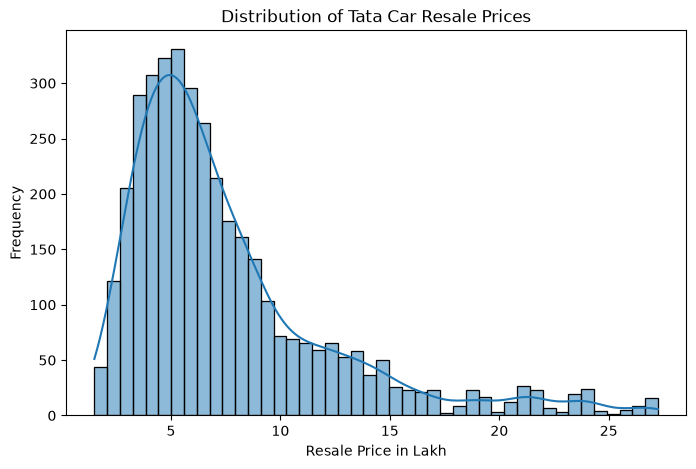

In [154]:
### EDA 1 - Resale Price Distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["resale_price_lakh"], kde=True)
plt.title("Distribution of Tata Car Resale Prices")
plt.xlabel("Resale Price in Lakh")
plt.ylabel("Frequency")
plt.show()

### Insight from Resale Price Distribution

This chart shows how resale prices are distributed across the dataset. It helps me understand whether most cars are within a similar price range or whether some cars are much more expensive than others.

This histogram chart shows that most cars are priced within the lower resale price range, mainly between **2 lakh and 10 lakh**.

The highest concentration of cars appears around **4 lakh to 6 lakh**, meaning many cars in the dataset are affordable or mid-range vehicles.

There are fewer cars with resale prices above **15 lakh**, and only a small number of cars are priced above **20 lakh**.

This means the resale price distribution is **right-skewed**, because most cars have lower prices while a few expensive cars stretch the price range higher.

Overall, most cars appear to be within the price range of **2 lakh to 10 lakh**.

### Understanding Right-Skewed Distribution

Skewness is a statistical concept used to describe whether data is balanced or stretched more to one side. It is commonly linked to Karl Pearson, who introduced Pearson’s skewness coefficients.

In this project, the resale price distribution is right-skewed because most Tata cars are priced between about **2 lakh and 10 lakh**, while only a few cars have very high resale prices above **15 lakh or 20 lakh**.

This creates a long tail on the right side of the chart. It shows that most cars are in the lower to mid-price range, but the model also needs to understand the few expensive cars in the dataset.

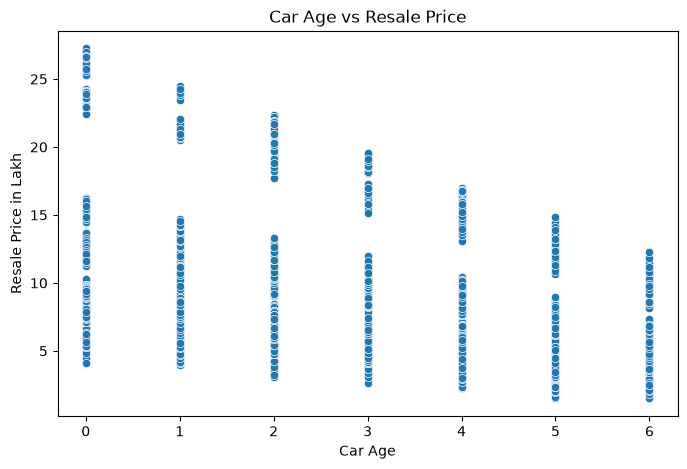

In [155]:
## EDA 2 -  Car age vs resale price

plt.figure(figsize=(8, 5))
sns.scatterplot(x="car_age", y="resale_price_lakh", data=df)
plt.title("Car Age vs Resale Price")
plt.xlabel("Car Age")
plt.ylabel("Resale Price in Lakh")
plt.show()

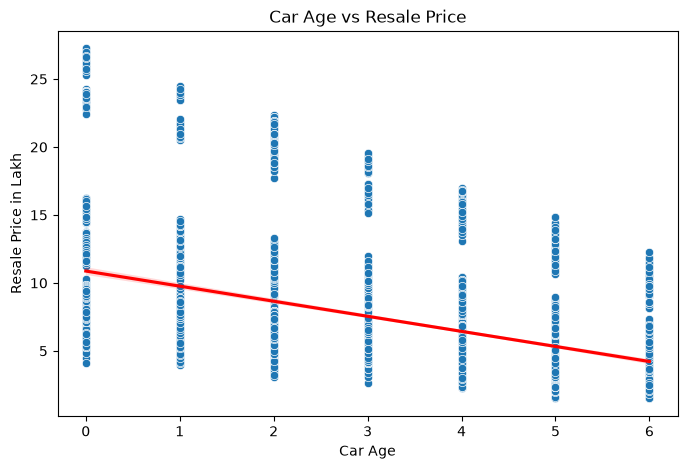

In [156]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="car_age", y="resale_price_lakh")
sns.regplot(x="car_age", y="resale_price_lakh", data=df, scatter=False, color="red")
plt.title("Car Age vs Resale Price")
plt.xlabel("Car Age")
plt.ylabel("Resale Price in Lakh")
plt.show()

### Insight from Car Age vs Resale Price

This scatter plot helps me understand whether older cars generally have lower resale prices. In a real-world car market, age is usually an important factor because cars depreciate over time.

These are the 2 major questions;
`Does resale price reduce as car age increases?`
`Are there any older cars that still have high resale value?`

Yes, the resale price generally decreases as car age increases.

From the scatter plot, newer cars have higher resale prices, while older cars mostly have lower resale prices. This shows a negative relationship between car age and resale price.

The trend line helps confirm this pattern because it slopes downward. This means that as the age of the car increases, the resale price tends to reduce.

However, there are still a few older cars with fairly high resale values. This may be because those cars have better features, lower kilometres driven, good condition, strong demand, or no accident history.

Overall, car age is an important factor in predicting resale price, but it is not the only factor.

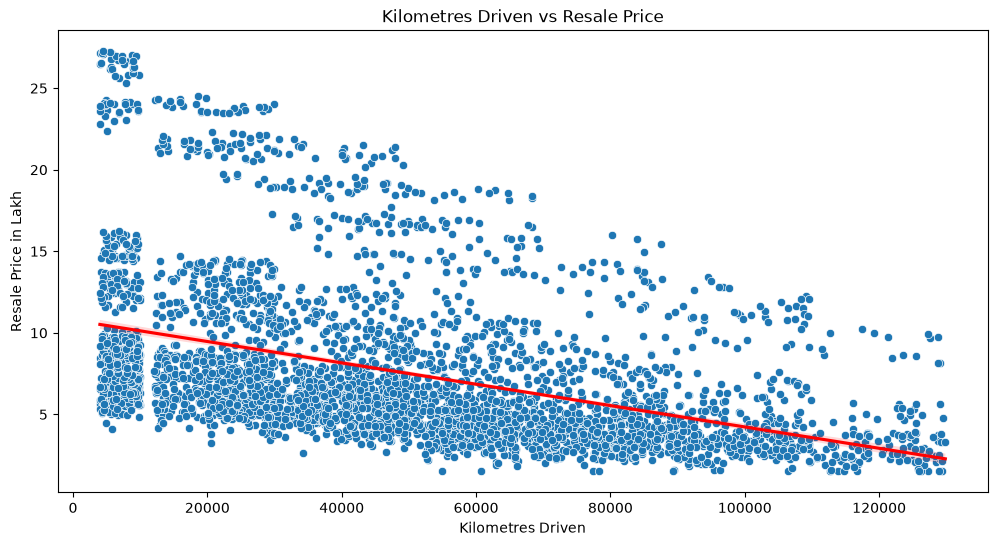

In [157]:
## EDA 3 - Kilometres driven vs resale price

plt.figure(figsize=(12, 6))
sns.scatterplot(x="kilometers_driven", y="resale_price_lakh", data=df)
sns.regplot(x="kilometers_driven", y="resale_price_lakh", data=df, scatter=False, color="red")
plt.title("Kilometres Driven vs Resale Price")
plt.xlabel("Kilometres Driven")
plt.ylabel("Resale Price in Lakh")
plt.show()

This chart shows the relationship between kilometres driven and resale price. Cars with higher kilometres drivrn may have lower resale value because they have experienced more usage. So, cars with higher kilometres driven generally have lower resale prices. The downward trend line shows a negative relationship between kilometres driven annd resale price, meaning that as a car is driven more, its resale value tends to reduce.

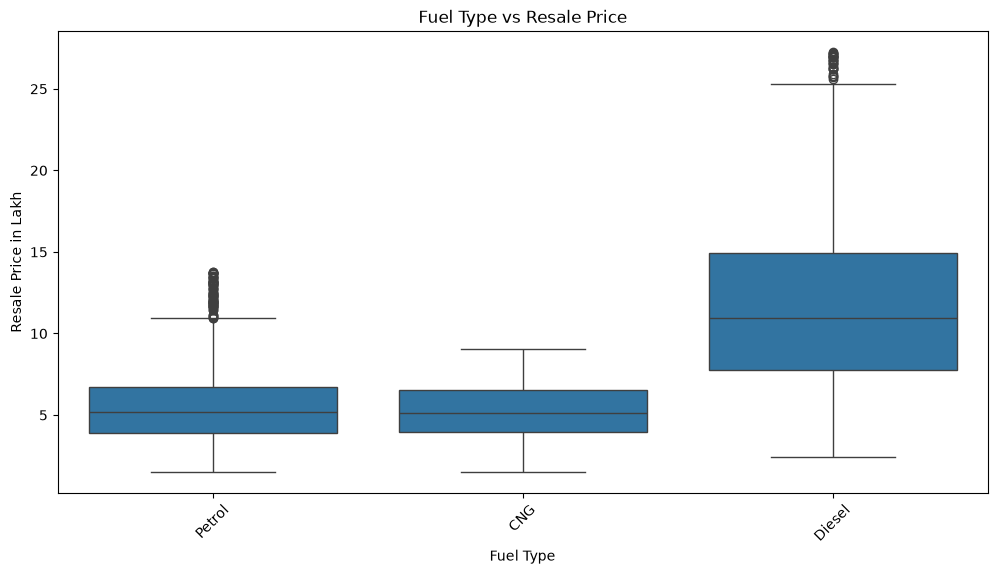

In [158]:
## EDA 4 - Fuel type vs resale price

plt.figure(figsize=(12, 6))
sns.boxplot(x="fuel_type", y="resale_price_lakh", data=df)
plt.title("Fuel Type vs Resale Price")
plt.xlabel("Fuel Type")
plt.ylabel("Resale Price in Lakh")
plt.xticks(rotation=45)
plt.show()

## Observation from Fuel Type vs Resale Price

Diesel cars appear to have the highest resale prices compared to petrol and CNG cars.

From the boxplot, desel cars have a wider price range, meaning their resale prices vary more. Some diesel cars also have very high resale prices, which appear as outliers.

Petrol cars have moderate resale prices, while CNG cars generally have the lowest resale prices in the dataset.

Overall, the fuel type seems to affect resale price, with diesel cars generally having better resale value.

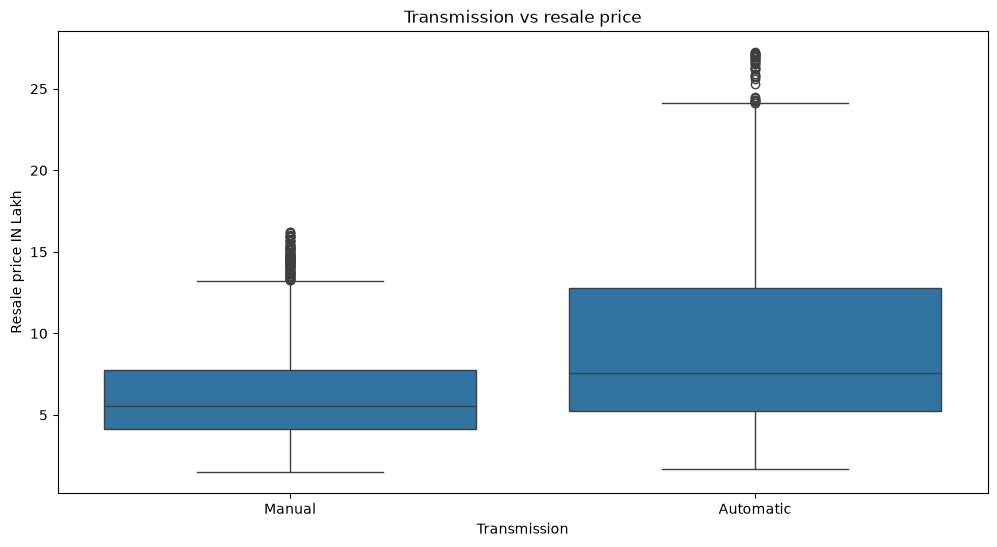

In [159]:
## EDA 5 - Transmission vs resale price

plt.figure(figsize=(12, 6))
sns.boxplot(x="transmission", y="resale_price_lakh", data=df)
plt.title("Transmission vs resale price")
plt.xlabel("Transmission")
plt.ylabel("Resale price IN Lakh")
plt.show()

## Observation from Transmission vs resale price

Automatic cars appear to have a wider resale price range compared to Manual Cars.

From the boxplot, automatic cars have some very high resale prices, shown by the upper whisker and outlier points. This means some automatic cars are sold at much higher prices in the dataset.

Manual cars have a more stable and smaller price range, with most resale prices staying within the lower to mid-price range.

Overall, transmission type seems to affect resale price, and automatic cars may have higher resale value for some models.


In [160]:
df.columns

Index(['brand', 'model', 'variant', 'fuel_type', 'transmission', 'body_type',
       'engine_cc', 'power_bhp', 'mileage_kmpl', 'ex_showroom_price_lakh',
       'year', 'kilometers_driven', 'owner_count', 'accident_history',
       'resale_price_lakh', 'car_age'],
      dtype='str')

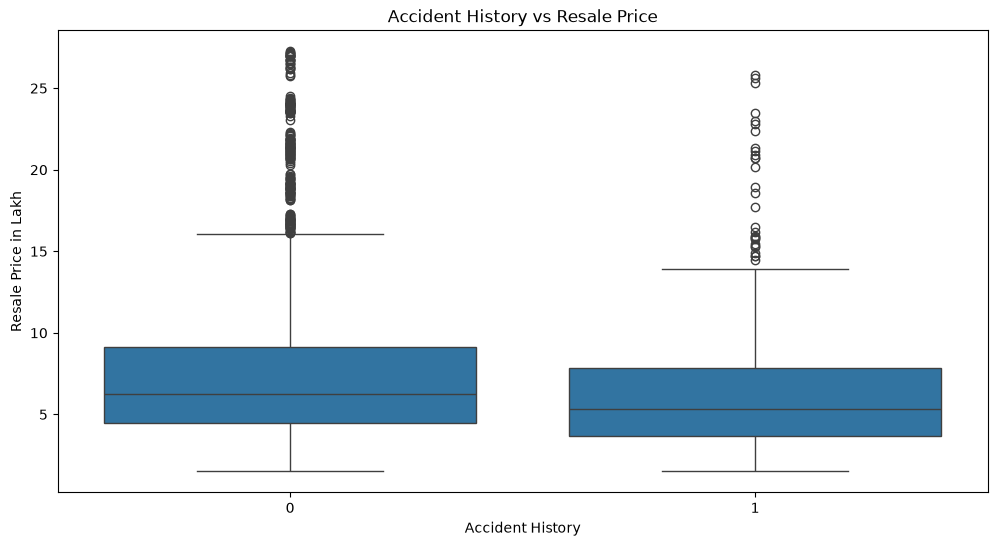

In [161]:
## EDA 6 - Accident history vs resale price

plt.figure(figsize=(12, 6))
sns.boxplot(
    x="accident_history", 
    y="resale_price_lakh", 
    data=df
)
plt.title("Accident History vs Resale Price")
plt.xlabel("Accident History")
plt.ylabel("Resale Price in Lakh")
plt.show()

## Observation from Accudent History vs Resale Price

Cars with no accident history generally have higer resale prices than cars with accident history.

From the boxplot, cars without accident history have a wider and higher resale price range, while carswith accident history mostly stay in the lower price range.

This shows that accident history can reduce a car's resale value because buyers usually prefer cars with a clean record.

Overall, accident history is an important feature because it can affect buyer confidence and the final resale price of a car.

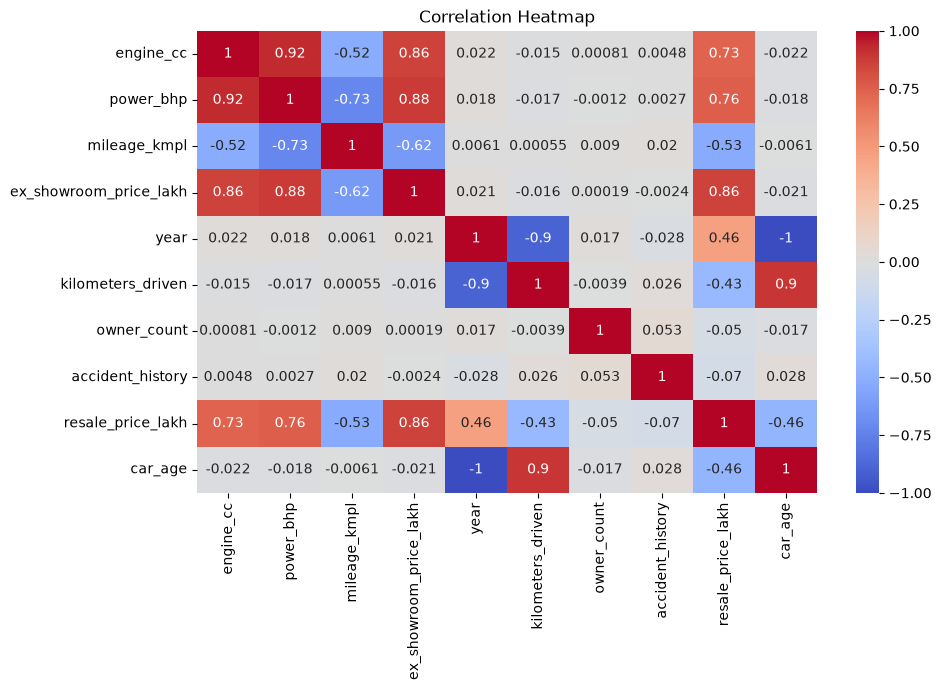

In [162]:
## EDA 7 - Correlation heatmap

plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include=["int64", "float64"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [163]:
df.columns

Index(['brand', 'model', 'variant', 'fuel_type', 'transmission', 'body_type',
       'engine_cc', 'power_bhp', 'mileage_kmpl', 'ex_showroom_price_lakh',
       'year', 'kilometers_driven', 'owner_count', 'accident_history',
       'resale_price_lakh', 'car_age'],
      dtype='str')

### Correlation Explanation and observations

A correlation heatmap is used to show the relationship between numerical columns in the dataset.

Correlation tells how strongly two columns are related.

- A value close to **1** means a strong positive relationship.
- A value close ro **0** means little or no relationship.
- A value close to **-1** means a strong negative relationship.

In this project, the heatmap helps to understand which features are strongly connected to `resale_price_lakh`.

The strongest positive relationship with `resale_price_lakh` is `ex_showroom_price_lakh`, with a correlation of about **0.86**. This means cars with original showroom prices usually have higher resale prices.

`power_bhp` and `engine_cc` also have positive relationships with `resale_price_lakh`. Ths suggests that more powerful cars and cars with bigger engines may have higher resale values.

`kilometers_driven` has a negative relationship with `resale_price_lakh`. This means cars that have been driven more usually have lower resale prices.

`mileage_kmpl` has a negative relationship with ``resale_price_lakh`, around **-0.53**. This means cars with higher mileage may often have lower resale prices.

`car_age` also has a negative relationship with `resale_price_lakh`. This means older cars generally lose value over time.

Overall, the heatmap shows that original showroom price, engine power, engine size, mileage, and car age are important features for predicting resale price.



### Phase 9: EDA Findings

From the EDA Charts, I personally observed that resale price is influenced by several important features in the dataset.

One interesting observation I noticed is that cars with higher `ex_showroom_price_lakh` generally have higher `resale_price_lakh`. This means the original price of the car is one of the strongest indicators of its resale value.

The resale price distribution is `right-skewed`. Most Tata cars in the dataset are within the lower to mid-price range, while only a few cars have very high resale prices. This shows that expensive cars are less common in the dataset.

`Car_age` appears to be important because olde cars usually have lower resale prices. This makes sense because cars normally lose value overtime sue to ageing, usage, and depreciation.

`kilometers_driven` also seems to affect resale price. Cars with very high kilometres driven generally have lower resale prices because they have been used more.

`fuel_type` also shows some difference in resale price. Diesel cars appears to have higher resale prices and a wider price range compared to petrol and CNG cars. CNG cars generally appear to have lower resale prices.

`Transmission` type also seemsto affect resale price. Automatic cars have a wider resale price range and some very high resale values, while manual cars appear more stable and mostly stay within the lower to mid-price range.

`Accident_history` is another important factor. Cars eith no accident history generally have better resale prices than cars with accident history. This is because buyers usually prefer cars with a clean accident record.

The correlation heatmap also supports these findings. `ex_showroom_price_lakh`, `power_bhp` and `engine_cc`have positive relationship with `resale_price_lakh`. while `car_age`, `kilometers_driven`, and `mileage_kmpl` show negative relationships with `resale_price_lakh`.

Overall, the most important features for predicting resale price appear to be original showroom price, car age, kilometres driven, engine power, fuel type, transmission type, and accident history.







### Phase 10: Preparing Data for ML Modelling

Before training the model, need to separate the input features from the target variable. The input features will be used to predict the resale price, while he target variable is the resale price itself.

In [164]:
X = df.drop(columns=[target])
y = df[target]

`X` contains the independent variables, also called features. These are the columns the model will train from.
`y` contains the dependent variables, which is the resale price the model is trying to predict.

In [165]:
X.head

<bound method NDFrame.head of      brand   model          variant fuel_type transmission  body_type  \
0     Tata   Tiago               XE    Petrol       Manual  Hatchback   
1     Tata   Tiago               XE    Petrol       Manual  Hatchback   
2     Tata   Tiago               XE    Petrol       Manual  Hatchback   
3     Tata   Tiago               XE    Petrol       Manual  Hatchback   
4     Tata   Tiago               XE    Petrol       Manual  Hatchback   
...    ...     ...              ...       ...          ...        ...   
3795  Tata  Safari  Accomplished AT    Diesel    Automatic        SUV   
3796  Tata  Safari  Accomplished AT    Diesel    Automatic        SUV   
3797  Tata  Safari  Accomplished AT    Diesel    Automatic        SUV   
3798  Tata  Safari  Accomplished AT    Diesel    Automatic        SUV   
3799  Tata  Safari  Accomplished AT    Diesel    Automatic        SUV   

      engine_cc  power_bhp  mileage_kmpl  ex_showroom_price_lakh  year  \
0          1199    

In [166]:
y.head()

0    4.48
1    3.18
2    3.18
3    4.06
4    3.43
Name: resale_price_lakh, dtype: float64

### Checking X and y

I used `X.head()` to view the first five rows of the independent variables, also called the features. 

I used `y.head()` to view the first five values of the dependent variable, which is the target column. 

This step helps me confirm that the features and target were separated correctly before training the machine learning model.

## Phase 11 - Train-Test Split

This dataset is split into training and testing sets. The training set is used to teach/train the model, while the testing set is used to evaluate how well the model performs on unseen data.

In [167]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

I used 80% ofthe data for training and 20% for testing, The `random_state=42` ensures that the split is reproducible, meaning the same split can be generated again. 

In [168]:
# Checking the sizes

X_train.shape, X_test.shape

((3040, 15), (760, 15))

## Phase 12 - Data Preprocessing Pipeline

The dataset contains both numerical and categorical features. Machine learning models require numerical input, so categorical columns must be converted into numerical format.

To handle this, I use a preprocessing pipeline. Numerical columns are filled and scaled, while categorical columns are encoded using one-hor encoding.



In [169]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [170]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns

numeric_features

Index(['engine_cc', 'power_bhp', 'mileage_kmpl', 'ex_showroom_price_lakh',
       'year', 'kilometers_driven', 'owner_count', 'accident_history',
       'car_age'],
      dtype='str')

In [171]:
categorical_features = X_train.select_dtypes(include=["object"]).columns

categorical_features

C:\Users\Udoch\AppData\Local\Temp\ipykernel_28740\476141337.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include=["object"]).columns


Index(['brand', 'model', 'variant', 'fuel_type', 'transmission', 'body_type'], dtype='str')

The numerical and categorical columns are separated because they need different preprocessing steps.

In [172]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scalar", StandardScaler())
])

For numerical columns, missing values are filled using the median. Thevalues are then scaled so that large numerical ranges do not dominate smaller ones.

In [173]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

For categorical columns, missing values are filled using the most frequent value. One-hot encoding is then used to convert text categorical into numerical columns that the model can umderstand.

In [174]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

The `ColumnTransformer` combines the numerical and categorical preprocessing steps into one object. This makes the workflow cleaner  and also prevents mistakes during model training and deployment.

## Phase 13 - Build baseline Model

I start with Linear Regression as a baseline model. A baseline model gives me a simple starting point so i can compare whether more advanced models perform better. 

In [175]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

The Linear Regression model is placed inside the pipeline togethe with the preprocessing steps. This means the data will be cleaned, transfomed and passed into the model in one workflow.

In [176]:
## Training fit

linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['brand','model','variant',...,'owner_count','accident_history','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [177]:
## Predicting

y_pred_linear = linear_model.predict(X_test)

In [178]:
### Evaluating 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R2 Score:", r2_linear)

Linear Regression Results
MAE: 0.780429467728205
RMSE: 1.1631553217789765
R2 Score: 0.9425389850022966


### Linear Regression Model Results Interpretation

The model is evaluated using MAE, RMSE, and R2 Score and it performs well as a baseline model.

The **MAE is about 0.78 lakh**, which means that, on average, the model's resale price prediction is off by around **0.78 lakh** from the actual resale price.

The **RMSE** is about 1.16 lakh. This means the model's larger errors are around **1.16**. Since RMSE is higher than MAE, it shows that some predictions have slightly larger errors.

The **R2 score is 0.94**, which means the model explains about **94% of the variation** in resale price.

However, the Linear Regression model performed very well as a baseline model. the low MAE and RMSE show that the prediction errors are not too large, while the high R2 score shows that the model understands most of the patterns in the dataset.

## Phase 14 - Building stronger Model Using Random Forest Regressor

After building a baseline model, I traiin a Random Forest Regressor. Random Forest is useful because car prices may depend on complex non-linear relationships between features.

In [179]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

In [180]:
### Training

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['brand','model','variant',...,'owner_count','accident_history','car_age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [181]:
### Predicting 

y_pred_rf = rf_model.predict(X_test)

In [182]:
### Evaluating

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_absolute_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Results
MAE: 0.23825065131578999
RMSE: 0.4881092616574592
R2 Score: 0.9962796673590932


### Random Forest Model Results Interpretation

The Random Forest model performed very well on the test data.

The **MAE is about 0.24 lakh**, which means that, on average, the model’s prediction is off by only about **0.24 lakh** from the actual resale price. This is a small error, so the model is making close predictions.

The **R² score is about 0.996**, which means the model explains about **99.6% of the variation** in resale price. This shows that the Random Forest model learned the patterns in the dataset very well.

Compared to the Linear Regression model, the Random Forest model performs better because it has a lower error and a higher R² score. This is expected because Random Forest can capture more complex relationships between features such as car age, kilometres driven, fuel type, transmission, accident history, and resale price.

Overall, Random Forest is the stronger model for this car resale price prediction project.

## Building Additional Regression Models

After training L.R and R.F Regression Models, I decided to builde more regression models to compare their performance. 

For this car resale price prediction project, the resale value of a car may depend on several working together, such as car age, mileage, accident history, fuel type, transmission, engine size, and original showroom price.

By comparing multiple models, I can make a more informed decision about which model is most suitable for deployment.

In [183]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

The additional regression models are imported from Scikit-learn. These models allow me to compare linear, tree-based, ensemble, boosting, and distance-based regression approaches.

Ridge Regression       = improved linear model that reduces overfitting
Lasso Regression       = linear model that can reduce unimportant features
Decision Tree          = learns rule-based patterns
Extra Trees            = advanced tree ensemble model
Gradient Boosting      = builds models step by step to correct errors
KNN Regressor          = predicts price based on similar cars

## Build Ridge Regression

Ridge Regression is an improved version of Linear Regression. It is useful when some features are regularisation to reuce overfitting.

In this project. Ridge Regression helps me check whether a regularised linear model performs better than basic Linear Regression.

In [184]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

In [185]:
## Evaluating

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge =  np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression Results")
print("MAE:", mae_ridge)
print("RMSE:", rmse_ridge)
print("R2 Score:", r2_ridge)

Ridge Regression Results
MAE: 0.7801650190020876
RMSE: 1.1629880605210383
R2 Score: 0.942555509554851


### Ridge Regression Compared with Linear Regression

From the result, Ridge Regression performed very close to the Linear Regression model.

The **MAE is about 0.78 lakh**, the **RMSE is about 1.16 lakh**, and the **R² score is about 0.94**. These results are almost the same as the Linear Regression results.

This shows that adding Ridge regularisation did not significantly improve the model performance.

This may mean that the Linear Regression model was already performing well and the dataset does not have a serious overfitting problem for this model.

However, Ridge Regression is still useful because it helps control overfitting, but in this project, it did not perform much better than Linear Regression.

Ridge Regression gave almost the same performance as Linear Regression, so the regularisation did not make a major difference in this dataset.

### Build Lasso Regression

Lasso Regression is another regularised linear model. It can redduce the effect of less important features by shrinking some coefficients towards zero.

This is useful in a dataset with many encoded categorical features because one-hot encoding can create several new columns

In [186]:
##Training the model

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.01, max_iter=1000))
])

lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

In [187]:
## Evaluating/Testing the model

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_absolute_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression Results")
print("MAE:", mae_lasso)
print("RMSE:", rmse_lasso)
print("R2 Score:", r2_lasso)

Lasso Regression Results
MAE: 0.7758002228131305
RMSE: 0.8807952218382719
R2 Score: 0.9428144151372786


This result is very close to the Linear Regression and Ridge Regression models. This means Lasso Regression did not make a major improvement in this dataset.

Lasso Regression is still useful because it can reduce the effect of less important features, especially when there are many encoded categorical columns.

Overall, Lasso Regression performed well, but its performance is almost the same as Linear Regression and Ridge Regression.

## Decision Tree Regressor

A Decision Tree Regressor learns rule-based patterns from the data. It can capture non-linear relationships between features and resale price.

This is useful because car resale price may not always follow a straight-line relationship. However, Decision Trees can overfit, so I control the tree depth.

In [188]:
## Training the model

decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

y_pred_dt = decision_tree_model.predict(X_test)

In [189]:
## Testing the Decision Tree Model

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

Decision Tree Results
MAE: 0.2712617822801752
RMSE: 0.3457467923711269
R2 Score: 0.9949229178755178


The Decision Tree Regressor performed very well. It performs better than Linear Regression, Ridge Regression, and Lasso Regression because it has lower error values and a higher R² score.

This shows that the relationship between car features and resale price may not be purely linear. The Decision Tree model can capture more complex patterns in the dataset.

However, Decision Trees can sometimes overfit, so using `max_depth=10` helps control the model by limiting how deep the tree can grow and prevents it from becoming too complex or overfitting.

### Build Gradient Boosting Regressor

## Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble model that builds trees sequentially. Each new tree tries to correct the errors made by the previous trees.

This model is useful for tabular regression problems because it can learn complex relationships between features and the target variable.

In [190]:
## Training the model

gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

In [191]:
### Testing the model

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)

Gradient Boosting Results
MAE: 0.2137418104610431
RMSE: 0.2544175472938903
R2 Score: 0.9972508907947707


### Gradient Boosting Regressor Results Interpretation

The Gradient Boosting Regressor was evaluated using MAE, RMSE, and R² score.

The **MAE is about 0.21 lakh**, which means that, on average, the model’s resale price prediction is off by about **0.21 lakh** from the actual resale price.

The **RMSE is about 0.25 lakh**, which means the model has very low prediction error, even when larger errors are considered.

The **R² score is about 0.997**, which means the model explains about **99.7% of the variation** in resale price.

Overall, the Gradient Boosting Regressor performed extremely well. It performed better than Linear Regression, Ridge Regression, Lasso Regression, and Decision Tree because it has lower error values and a higher R² score.

This shows that Gradient Boosting is very effective for this car resale price prediction project because it can learn complex patterns from features such as car age, kilometres driven, fuel type, transmission, accident history, engine size, and showroom price.

## K-Nearest Neighbors Regressor

KNN Regressor predicts the resale price of a car by comparing it with similar cars in the training dataset.

This model is useful as a simple comparison model because it does not learn a formula. Instead, it makes predictions based on similarity.

In [192]:

## Training 

knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(
        n_neighbors=5
    ))
])

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

In [193]:
## Testing 

mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("KNN Regressor Results")
print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

KNN Regressor Results
MAE: 0.27842631578947363
RMSE: 0.3764411186221208
R2 Score: 0.9939814485203504


Why n_neighbors=5? `The model looks at the 5 most similar cars before making a prediction.`

### KNN Regressor Results Interpretation

The K-Nearest Neighbors Regressor was evaluated using MAE, RMSE, and R² score.

The **MAE is about 0.28 lakh**, which means that, on average, the model’s resale price prediction is off by about **0.28 lakh** from the actual resale price.

The **RMSE is about 0.38 lakh**, which means the model has low prediction error, even when larger errors are considered.

The **R² score is about 0.994**, which means the model explains about **99.4% of the variation** in resale price.

Overall, the KNN Regressor performed very well. It shows that comparing a car with similar cars in the training dataset can give strong resale price predictions.

However, compared with models like Random Forest and Gradient Boosting, KNN may be slower on larger datasets because it needs to compare new data points with existing data points before making predictions.

### Build Extra Trees Regressor

Extra Trees Regressor is an ensemble model that builds many decision trees and combines their predictions.

It is similar to Random Forest, but it introduces more randomness when creating the trees. This can sometimes improve generalisation and reduce overfitting.

In [194]:
## Training the model

extra_trees_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

extra_trees_model.fit(X_train, y_train)

y_pred_extra = extra_trees_model.predict(X_test)

In [195]:
mae_extra = mean_absolute_error(y_test, y_pred_extra)
rmse_extra = np.sqrt(mean_squared_error(y_test, y_pred_extra))
r2_extra = r2_score(y_test, y_pred_extra)

print("Extra Trees Results")
print("MAE:", mae_extra)
print("RMSE:", rmse_extra)
print("R2 Score:", r2_extra)

Extra Trees Results
MAE: 0.2524740789473706
RMSE: 0.3146351375052151
R2 Score: 0.9957955197920282


Why n_estimators=300?
- It builds 300 trees.
- More trees can improve stability, but it may take longer to train.

Why n_jobs=-1?
- It uses all available CPU cores to train faster.

### Extra Trees Regressor Results Interpretation

The Extra Trees Regressor was evaluated using MAE, RMSE, and R² score.

The **MAE is about 0.25 lakh**, which means that, on average, the model’s resale price prediction is off by about **0.25 lakh** from the actual resale price.

The **RMSE is about 0.31 lakh**, which means the model has low prediction error, even when larger errors are considered.

The **R² score is about 0.996**, which means the model explains about **99.6% of the variation** in resale price.

Overall, the Extra Trees Regressor performed very well. It shows that tree-based ensemble models are very effective for this car resale price prediction project.

Compared with Linear Regression, Ridge Regression, and Lasso Regression, the Extra Trees model performs much better because it has lower error values and a higher R² score.

This means the model is able to capture complex patterns between features such as car age, kilometres driven, fuel type, transmission, engine size, power, accident history, and resale price.

### Phase 15: Compare all models together

After training all regression models, I compare their performance using MAE, RMSE, nd R2 Score.

The best model should have:
- Lower MAE
- Lower RMSE
- Higher R2 Score

For this project, MAE is especially useful because it tells the average prediction error in lakhs.

In [196]:
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor",
        "Gradient Boosting Regressor",
        "KNN Regressor",
        "Extra Trees Regressor"
    ],
    "MAE": [
        mae_linear,
        mae_lasso,
        mae_ridge,
        mae_dt,
        mae_rf,
        mae_extra,
        mae_gb,
        mae_knn
    ],
    "RMSE": [
        rmse_linear,
        rmse_lasso,
        rmse_ridge,
        rmse_dt,
        rmse_gb,
        rmse_extra,
        rmse_rf,
        rmse_knn
    ],
    "R2 Score": [
        r2_linear,
        r2_lasso,
        r2_ridge,
        r2_dt,
        r2_rf,
        r2_gb,
        r2_knn,
        r2_extra
    ]
})

model_results = model_results.sort_values(by="MAE", ascending=True)

model_results

,Model,MAE,RMSE,R2 Score
6,KNN Regressor,0.213742,0.488109,0.993981
4,Random Forest Regressor,0.238251,0.254418,0.996280
5,Gradient Boosting Regressor,0.252474,0.314635,0.997251
3,Decision Tree Regressor,0.271262,0.345747,0.994923
7,Extra Trees Regressor,0.278426,0.376441,0.995796
1,Ridge Regression,0.775800,0.880795,0.942814
2,Lasso Regression,0.780165,1.162988,0.942556
0,Linear Regression,0.780429,1.163155,0.942539


### Key Observations

The **KNN Regressor** has the lowest MAE of about **0.21 lakh**, meaning it has the lowest average prediction error.

The **Random Forest Regressor** has the lowest RMSE of about **0.25 lakh**, meaning it handles larger prediction errors better than the other models.

The **Gradient Boosting Regressor** has the highest R² score of about **0.997**, meaning it explains the highest percentage of variation in resale price.

The linear models — **Linear Regression, Ridge Regression, and Lasso Regression** — performed well, but they were weaker than the tree-based and ensemble models. Their R² scores are around **0.94**, while the stronger models have R² scores above **0.99**.

### Best Model Choice

Although KNN has the lowest MAE, the **Random Forest Regressor** and **Gradient Boosting Regressor** look more reliable overall because they have very low errors and very high R² scores.

For this project, I would choose **Gradient Boosting Regressor** as the best overall model because it has the highest R² score and still has very low MAE and RMSE.

This shows that Gradient Boosting can learn complex relationships between car features and resale price better than the simpler linear models.

### Why I Sorted by MAE

I sorted the model comparison table by MAE because MAE shows the average prediction error in lakh, which is easy to understand for this car resale price prediction project.

A lower MAE means the model makes smaller average mistakes when predicting resale price.

However, MAE should not be the only metric used to choose the best model. I also need to check RMSE and R² score.

RMSE is important because it gives more weight to larger errors. A model with a low RMSE is better at avoiding big prediction mistakes.

R² score is also important because it shows how much of the resale price variation the model can explain.

Therefore, since the best model should have:

- Low MAE
- Low RMSE
- High R² score

In this project, sorting by MAE helps me see the model with the lowest average error first, but the final model decision should be based on all three metrics together.

### Rank each model using all three metrics

MAE Rank: lower MAE gets better rank
RMSE Rank: lower RMSE gets better rank
R2 Rank: higher R² gets better rank

In [197]:
# Rank each model using all three metrics
model_results["MAE Rank"] = model_results["MAE"].rank(ascending=True)
model_results["RMSE Rank"] = model_results["RMSE"].rank(ascending=True)
model_results["R2 Rank"] = model_results["R2 Score"].rank(ascending=False)

# Create overall ranking score
model_results["Overall Rank Score"] = (
    model_results["MAE Rank"] +
    model_results["RMSE Rank"] +
    model_results["R2 Rank"]
)

#Sort the models by overall performance
model_results = model_results.sort_values(
    by="Overall Rank Score",
    ascending=True
)

#Display final comparison table
model_results

,Model,MAE,RMSE,R2 Score,MAE Rank,RMSE Rank,R2 Rank,Overall Rank Score
4,Random Forest Regressor,0.238251,0.254418,0.996280,2.0,1.0,2.0,5.0
5,Gradient Boosting Regressor,0.252474,0.314635,0.997251,3.0,2.0,1.0,6.0
6,KNN Regressor,0.213742,0.488109,0.993981,1.0,5.0,5.0,11.0
3,Decision Tree Regressor,0.271262,0.345747,0.994923,4.0,3.0,4.0,11.0
7,Extra Trees Regressor,0.278426,0.376441,0.995796,5.0,4.0,3.0,12.0
1,Ridge Regression,0.775800,0.880795,0.942814,6.0,6.0,6.0,18.0
2,Lasso Regression,0.780165,1.162988,0.942556,7.0,7.0,7.0,21.0
0,Linear Regression,0.780429,1.163155,0.942539,8.0,8.0,8.0,24.0


In [198]:
# Selecting the best model automatically

best_model_name = model_results.iloc[0]["Model"]
best_model_mae = model_results.iloc[0]["MAE"]
best_model_rmse = model_results.iloc[0]["RMSE"]
best_model_r2 = model_results.iloc[0]["R2 Score"]

print("Best Model:", best_model_name)
print("Best MAE:", best_model_mae)
print("Best RMSE:", best_model_rmse)
print("Best R2 Score:", best_model_r2)

Best Model: Random Forest Regressor
Best MAE: 0.23825065131578999
Best RMSE: 0.2544175472938903
Best R2 Score: 0.9962796673590932


### Best Overall Model Selection Interpretation

To choose the best model, I compared all models using **MAE**, **RMSE**, and **R² score** together.

For this ranking:

- Lower **MAE** is better because it means lower average prediction error.
- Lower **RMSE** is better because it means fewer large prediction errors.
- Higher **R² score** is better because it means the model explains more variation in resale price.

From the overall ranking, the **Random Forest Regressor** is the best overall model. It has the lowest overall rank score of **5.0**.

The Random Forest model has:

- **MAE:** 0.238251
- **RMSE:** 0.254418
- **R² Score:** 0.996280

Although KNN has the lowest MAE, Random Forest performs better overall because it has the best RMSE and a very strong R² score.

Gradient Boosting also performed very well, with the highest R² score, but Random Forest has the best balance across all three metrics.

The linear models — Linear Regression, Ridge Regression, and Lasso Regression — performed weaker compared to the tree-based models because they had higher MAE and RMSE values.

Overall, the **Random Forest Regressor** is selected as the best final model because it gives the best balanced performance across MAE, RMSE, and R² score.

## Phase 17: Visualising Model Comparison Performance

A bar chart makes it easier to compare model errors visually. In this chart, the model with the lowest MAE is the best performing model based on average prediction error.

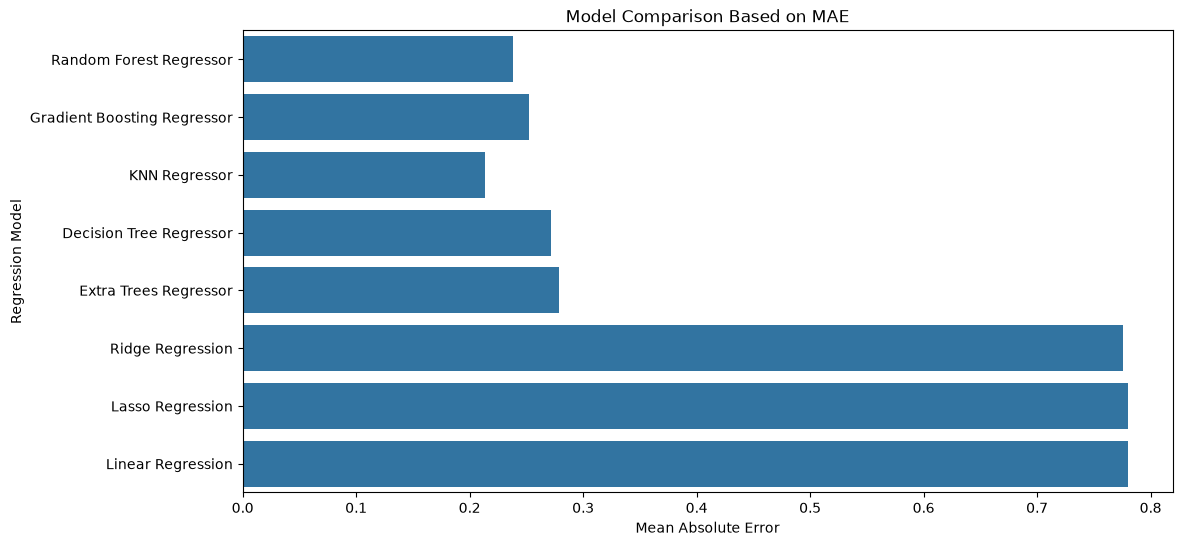

In [199]:
## MAE comparison

plt.figure(figsize=(12, 6))
sns.barplot(data=model_results, x="MAE", y="Model")
plt.title("Model Comparison Based on MAE")
plt.xlabel("Mean Absolute Error")
plt.ylabel("Regression Model")
plt.show()

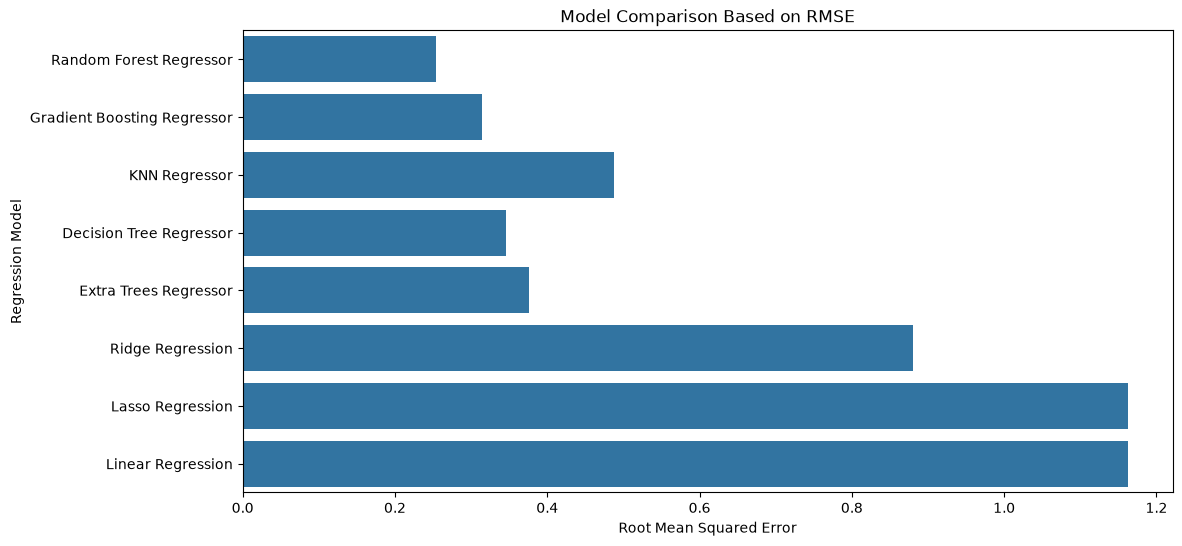

In [200]:
### RMSE comparison

plt.figure(figsize=(12, 6))
sns.barplot(data=model_results, x="RMSE", y="Model")
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Root Mean Squared Error")
plt.ylabel("Regression Model")
plt.show()

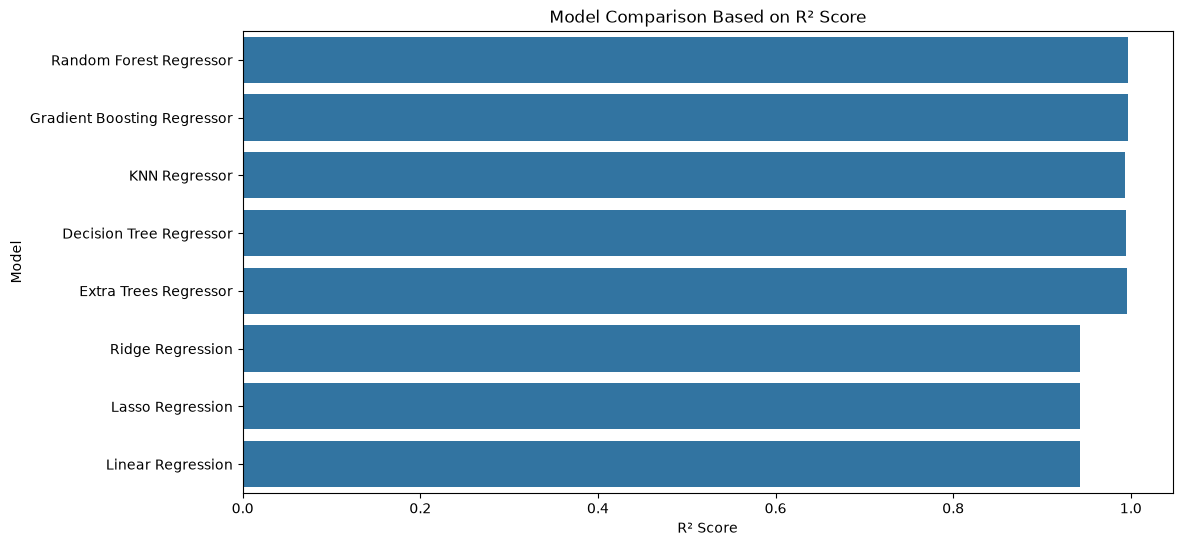

In [201]:
### R² score comparison

plt.figure(figsize=(12, 6))
sns.barplot(data=model_results, x="R2 Score", y="Model")
plt.title("Model Comparison Based on R² Score")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

## Interpretation of Model Comparison Bar Charts

The three bar charts compare the regression models using **MAE**, **RMSE**, and **R² score**.

### MAE Comparison

The MAE chart shows the average prediction error for each model. A lower MAE means the model makes smaller average mistakes.

From the MAE chart, the **KNN Regressor** has the lowest MAE, meaning it has the smallest average prediction error. Random Forest, Gradient Boosting, Decision Tree, and Extra Trees also performed well with low MAE values.

The linear models — Linear Regression, Ridge Regression, and Lasso Regression — have higher MAE values, meaning they made larger average errors compared to the non-linear models.

### RMSE Comparison

The RMSE chart shows how much larger prediction errors affect each model. A lower RMSE means the model handles large errors better.

From the RMSE chart, the **Random Forest Regressor** has the lowest RMSE. This means Random Forest is very good at reducing larger prediction mistakes.

Gradient Boosting, Decision Tree, Extra Trees, and KNN also have relatively low RMSE values, while the linear models have much higher RMSE values.

### R² Score Comparison

The R² score chart shows how much of the variation in resale price each model can explain. A higher R² score is better.

From the R² chart, the tree-based and ensemble models have the highest R² scores. Random Forest, Gradient Boosting, KNN, Decision Tree, and Extra Trees all explain more than 99% of the variation in resale price.

The linear models still performed well, but their R² scores are lower than the non-linear models.

### Overall Conclusion

The charts show that non-linear models performed better than the linear models.

KNN has the lowest MAE, Random Forest has the lowest RMSE, and Gradient Boosting has one of the highest R² scores.

However, when considering all three metrics together, the **Random Forest Regressor** appears to be the best overall model because it has a strong balance of low MAE, lowest RMSE, and very high R² score.

This means Random Forest is a reliable final model for predicting Tata car resale prices.

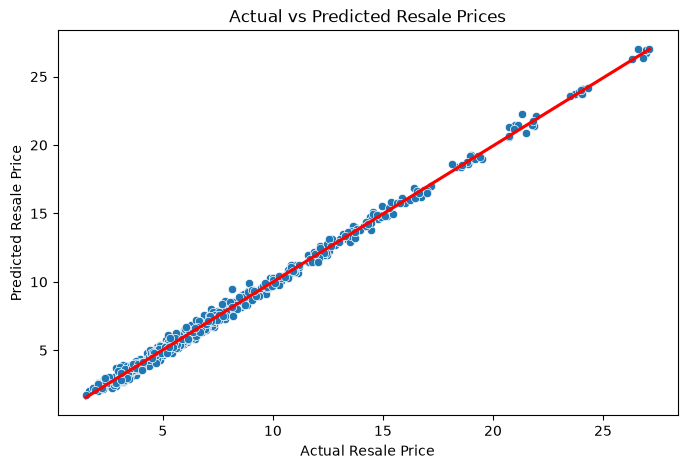

In [208]:
## Phase 18: Actual vs Predicted Prices

# To visually inspect model performance, I compare the actual resale prices with the predicted resale prices.

plt.figure(figsize=(8, 5))

sns.scatterplot(x=y_test, y=y_pred_rf)

sns.regplot(x=y_test, y=y_pred_rf, scatter=False, color="red")

plt.xlabel("Actual Resale Price")
plt.ylabel("Predicted Resale Price")
plt.title("Actual vs Predicted Resale Prices")

plt.show()

### Actual vs Predicted Resale Prices Interpretation

This chart compares the actual resale prices with the predicted resale prices from the final model.

The blue dots are very close to the red trend line, which means the model’s predictions are very close to the real resale prices.

As the actual resale price increases, the predicted resale price also increases in almost the same pattern. This shows that the model has learned the relationship between the car features and resale price very well.

There are only small gaps between the actual and predicted values, which means the model is making accurate predictions.

Finally, this chart confirms that the final model is performing strongly and can be trusted for predicting Tata car resale prices.

In [205]:
### Phase 19: Saving the best model selected from all metrics

#After selecting the best-performing model, I save it so it can be reused later in a deployment application without retraining.

trained_models = {
    "Linear Regression": linear_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model,
    "Decision Tree Regressor": decision_tree_model,
    "Random Forest Regressor": rf_model,
    "Gradient Boosting Regressor": gradient_boosting_model,
    "KNN Regressor": knn_model,
    "Extra Trees Regressor": extra_trees_model
}

best_model = trained_models[best_model_name]

In [214]:
# Saving the best model with joblib

import joblib
import os

joblib.dump(best_model, "../models/best_tata_car_price_model.joblib")
joblib.dump(list(X_train.columns), "../models/model_columns.joblib")


os.makedirs("../models", exist_ok=True)

In [217]:
## Saving feature options for Streamlit dropdowns

# Creating a feature_options.joblib

feature_options = {}

categorical_columns = [
    "brand",
    "model",
    "variant",
    "fuel_type",
    "transmission",
    "body_type"
]

for col in categorical_columns:
    if col in X_train.columns:
        feature_options[col] = sorted(X_train[col].dropna().unique().tolist())

joblib.dump(feature_options, "../models/feature_options.joblib")

feature_options

{'brand': ['Tata'],
 'model': ['Altroz', 'Harrier', 'Nexon', 'Punch', 'Safari', 'Tiago', 'Tigor'],
 'variant': ['Accomplished AT',
  'Adventure AMT',
  'Adventure CNG',
  'Creative DCA',
  'Fearless AT',
  'Pure',
  'Pure Diesel',
  'Smart',
  'XE',
  'XE CNG',
  'XT',
  'XT Diesel',
  'XTA',
  'XZA',
  'XZA DCA'],
 'fuel_type': ['CNG', 'Diesel', 'Petrol'],
 'transmission': ['Automatic', 'Manual'],
 'body_type': ['Compact SUV',
  'Hatchback',
  'Micro SUV',
  'Mid-Size SUV',
  'SUV',
  'Sedan']}

This will help your app create dropdowns for categorical columns like:

brand
model
variant
fuel_type
transmission
body_type

## Saving Category Options for the App

The categorical feature options are saved so that the Streamlit app can display dropdown menus instead of asking users to type values manually.

This improves the user experience and reduces spelling mistakes during prediction.

In [216]:
import joblib

feature_options = joblib.load("../models/feature_options.joblib")

feature_options

{}

## Saving the Best Model for Deployment

After comparing all regression models using MAE, RMSE, and R² score, I selected the best-performing model.

The final model is saved using Joblib so it can be reused later in the Streamlit app without retraining.

I also save the model input columns because the deployment app must use the same column structure that was used during training.

`Why this matters:`

best_model = the actual best model from your comparison table
model_columns = the exact input columns the model expects

## Phase 20: Streamlit Model Deployment Preparation


The final stage of the project is deployment. Deployment means making the model available in a simple application where users can enter car details and receive a resale price prediction.

After selecting and saving the best-performing regression model, I prepared the project for deployment using Streamlit.

The purpose of this phase is to move the machine learning model from the notebook environment into a simple interactive web application. In real-world machine learning projects, a model should not only perform well inside a notebook; it should also be usable by other people through an application or system.

For this project, I used Streamlit because it allows me to build a simple machine learning web app using Python. The app allows users to enter Tata car details such as brand, model, variant, fuel type, transmission, body type, engine size, power, mileage, ex-showroom price, manufacturing year, kilometres driven, owner count, and accident history.

The saved model is loaded into the Streamlit app using Joblib. I also saved the model input columns and categorical feature options so that the app can use the same structure that was used during model training.

This is important because the model expects the input data to have the same column names and format as the training data. If the app sends different columns or incorrect data types, the prediction may fail or become unreliable.

In the Streamlit app, categorical features such as brand, model, variant, fuel type, transmission, and body type are displayed as dropdown menus. This improves the user experience and reduces typing errors. Numerical features such as engine capacity, power, mileage, year, kilometres driven, and owner count are displayed as number input fields.

After the user enters the car details, the app converts the input into a Pandas DataFrame. This DataFrame is then passed into the saved machine learning pipeline to generate a resale price prediction.

The app also includes an Input Preview section, which allows the user to see the exact values being sent into the model before prediction. This makes the app more transparent and easier to debug.

The final prediction is displayed as an estimated resale price in lakhs.

This deployment phase demonstrates that the project goes beyond model training. It shows the complete workflow from data collection, cleaning, EDA, model building, model evaluation, model saving, and finally creating a usable prediction application.

### Streamlit Deployment Workflow

1. Save the best-performing machine learning model using Joblib.
2. Save the model input columns.
3. Save the categorical feature options for dropdown menus.
4. Create a Streamlit app file called `app.py`.
5. Load the saved model, model columns, and feature options inside the app.
6. Collect user input through dropdowns and number input fields.
7. Convert user input into a Pandas DataFrame.
8. Preview the input data inside the app.
9. Use the saved model to predict the resale price.
10. Display the predicted resale price to the user.

### Deployment Outcome

The Streamlit app successfully loads the trained model and generates resale price predictions based on user input. This makes the project more practical, interactive, and portfolio-ready.

The deployment stage helped me understand how a machine learning model can be moved from a notebook into a real application that users can interact with.

### Personal Reflection

This phase was very important for me because it helped me understand that machine learning is not only about training models. A professional ML project should also be usable, understandable, and presentable.

By building the Streamlit app, I was able to connect the trained model to a simple user interface. This gave me more confidence in how machine learning models can be deployed and used in a real-world environment.

This step also made the project stronger for my portfolio because employers can see that I understand the full machine learning lifecycle from raw data to deployment.

## Phase 21: Final Portfolio Preparation